# 📊 JobFit – End-to-End Data & Model Visualizations

This notebook shows detailed, colourful visualizations for your JobFit project:

- Data collection & dataset overview
- Country & category distributions (with **Unknown → Other Countries**)
- Job age & salary distributions
- Cluster model behaviour (KMeans)
- Embedding space (PCA projection)

> **Note:** Paths assume this notebook is in `notebooks/` inside your project root.


In [20]:
# Cell 1 – Imports & paths

import os
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
import joblib

# Make plots look nice
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams['figure.figsize'] = (8, 5)
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.labelsize'] = 12

# Project paths (notebook is in: project_root/notebooks/)
PROJECT_ROOT = Path.cwd().parent
DATA_DIR = PROJECT_ROOT / "data"
MODELS_DIR = PROJECT_ROOT / "models"

PROCESSED_JOBS_PATH = DATA_DIR / "processed" / "jobs.parquet"
CLUSTERED_JOBS_PATH = max((MODELS_DIR / "trained").glob("job_clusters_*.parquet"), default=None)
CLUSTER_MODEL_PATH = max((MODELS_DIR / "trained").glob("job_cluster_model_*.pkl"), default=None)

FIG_DIR = Path("figures")
FIG_DIR.mkdir(exist_ok=True)

PROJECT_ROOT, DATA_DIR, MODELS_DIR, PROCESSED_JOBS_PATH


(PosixPath('/Users/nishanthsakthivel/Documents/APPLIED-AI-GROUP/JobFit-main'),
 PosixPath('/Users/nishanthsakthivel/Documents/APPLIED-AI-GROUP/JobFit-main/data'),
 PosixPath('/Users/nishanthsakthivel/Documents/APPLIED-AI-GROUP/JobFit-main/models'),
 PosixPath('/Users/nishanthsakthivel/Documents/APPLIED-AI-GROUP/JobFit-main/data/processed/jobs.parquet'))

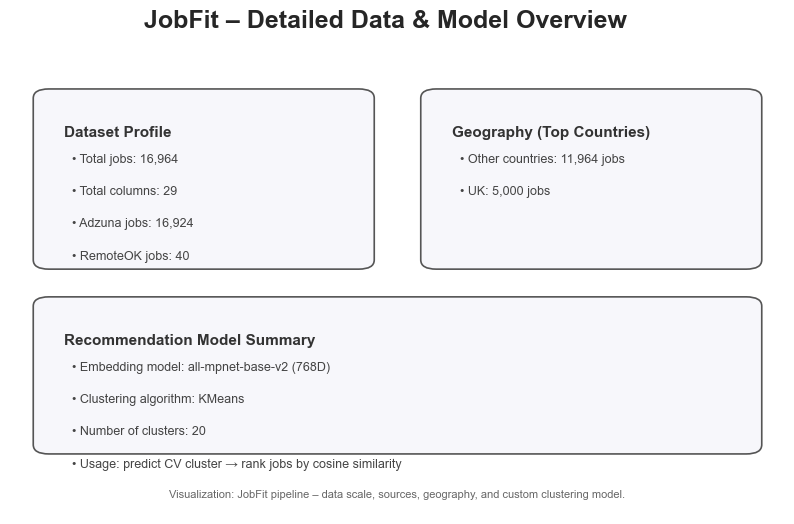

Saved summary dashboard to: notebook/figures/jobs_summary_dashboard.png


In [27]:
# Cell – Detailed overview visualization (summary dashboard)

import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch
from pathlib import Path

plt.style.use("seaborn-v0_8")

# Ensure figures directory exists
try:
    FIGURES_DIR
except NameError:
    FIGURES_DIR = Path("notebook/figures")
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

df = jobs  # main processed dataframe

# ---- Basic metrics ----
n_rows, n_cols = df.shape

# source counts
source_counts = df["source"].value_counts()
source_str = ", ".join(f"{k}: {v}" for k, v in source_counts.items())

# countries (using location_country, mapping missing to "Other/Unknown")
country_counts = df["location_country"].fillna("Other / Unknown").value_counts()
top_countries = country_counts.head(3)

# cluster info (from clustered dataframe if available)
cluster_col = None
if "df_clustered" in globals():
    for col in df_clustered.columns:
        if "cluster" in col.lower():
            cluster_col = col
            break

n_clusters = df_clustered[cluster_col].nunique() if cluster_col else "N/A"

# ---- Build figure ----
fig, ax = plt.subplots(figsize=(10, 6))
ax.axis("off")
fig.suptitle("JobFit – Detailed Data & Model Overview", fontsize=18, weight="bold", y=0.95)

def add_box(ax, x, y, width, height, title, lines):
    """Utility to draw a rounded box with title + bullet lines."""
    box = FancyBboxPatch(
        (x, y), width, height,
        boxstyle="round,pad=0.02",
        linewidth=1.2,
        edgecolor="#555555",
        facecolor="#f7f7fb",
    )
    ax.add_patch(box)
    ax.text(
        x + 0.02, y + height - 0.06,
        title,
        fontsize=11,
        weight="bold",
        color="#333333",
        ha="left",
        va="top",
    )
    text_y = y + height - 0.12
    for line in lines:
        ax.text(
            x + 0.03, text_y,
            "• " + line,
            fontsize=9,
            color="#444444",
            ha="left",
            va="top",
        )
        text_y -= 0.07

# Box 1 – Dataset
box1_lines = [
    f"Total jobs: {n_rows:,}",
    f"Total columns: {n_cols}",
    f"Adzuna jobs: {source_counts.get('adzuna', 0):,}",
    f"RemoteOK jobs: {source_counts.get('remoteok', 0):,}",
]
add_box(ax, 0.05, 0.55, 0.4, 0.35, "Dataset Profile", box1_lines)

# Box 2 – Geography
geo_lines = []
for country, count in top_countries.items():
    label = "Other countries" if country == "Other / Unknown" else country
    geo_lines.append(f"{label}: {count:,} jobs")
add_box(ax, 0.55, 0.55, 0.4, 0.35, "Geography (Top Countries)", geo_lines)

# Box 3 – Model & Clusters
model_lines = [
    "Embedding model: all-mpnet-base-v2 (768D)",
    f"Clustering algorithm: KMeans",
    f"Number of clusters: {n_clusters}",
    "Usage: predict CV cluster → rank jobs by cosine similarity",
]
add_box(ax, 0.05, 0.15, 0.9, 0.30, "Recommendation Model Summary", model_lines)

# Footer
ax.text(
    0.5, 0.03,
    "Visualization: JobFit pipeline – data scale, sources, geography, and custom clustering model.",
    fontsize=8,
    color="#666666",
    ha="center",
    va="bottom",
)

SUMMARY_PATH = FIGURES_DIR / "jobs_summary_dashboard.png"
plt.savefig(SUMMARY_PATH, dpi=300, bbox_inches="tight")
plt.show()

print(f"Saved summary dashboard to: {SUMMARY_PATH}")


=== DATASET OVERVIEW ===
Rows: 16,964   Columns: 29


,id,title,company,description,redirect_url,category_tag,category_label,location_display,location_country,location_region,...,job_age_days,source,collected_at,location,category,created,country,tags,url,created_at
0,5524944191,Campaign Analyst,Harnham - Data & Analytics Recruitment,"Campaign Analyst Up to £50,000 Hybrid - Stratf...",https://www.adzuna.co.uk/jobs/details/55249441...,it-jobs,IT Jobs,"Stratford-Upon-Avon, Warwickshire",UK,West Midlands,...,0.0,adzuna,2025-12-02T22:23:16.959451,None,None,None,None,None,None,None
1,5524944188,Platform Engineer - AWD,Reed,"Platform Engineer Annual Salary: upto £75,000 ...",https://www.adzuna.co.uk/jobs/details/55249441...,it-jobs,IT Jobs,"Bristol, South West England",UK,South West England,...,0.0,adzuna,2025-12-02T22:23:16.959538,None,None,None,None,None,None,None
2,5524944216,Z Scaler Analysts / Z Pa Analysts,Sanderson,Initally 6 months but likely to be at least 12...,https://www.adzuna.co.uk/jobs/details/55249442...,it-jobs,IT Jobs,"London, UK",UK,London,...,0.0,adzuna,2025-12-02T22:23:16.959525,None,None,None,None,None,None,None
3,5524944200,Platform Engineer - AWS,Reed,"Platform Engineer Annual Salary: upto £75,000 ...",https://www.adzuna.co.uk/jobs/details/55249442...,it-jobs,IT Jobs,"Somerset, South West England",UK,South West England,...,0.0,adzuna,2025-12-02T22:23:16.959505,None,None,None,None,None,None,None
4,5524944171,Contract Principal Data Engineer - eDV Cleared,Searchability NS&D,CONTRACT DATA ENGINEER - eDV CLEARED NEW CONTR...,https://www.adzuna.co.uk/jobs/details/55249441...,it-jobs,IT Jobs,"London, UK",UK,London,...,0.0,adzuna,2025-12-02T22:23:16.959562,None,None,None,None,None,None,None



=== COLUMN DATA TYPES ===


object     24
float64     5
Name: count, dtype: int64


=== MISSING VALUES SUMMARY ===


,Missing Count,Missing %
created_at,16924,99.76
url,16924,99.76
tags,16924,99.76
country,14961,88.19
latitude,13421,79.11
longitude,13421,79.11
location_city,13109,77.28
location_region,12353,72.82
created_date,11964,70.53
job_age_days,11964,70.53


/var/folders/jj/vjml5tzs5tngzhp902pqcb2m0000gn/T/ipykernel_67509/3077678027.py:46: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


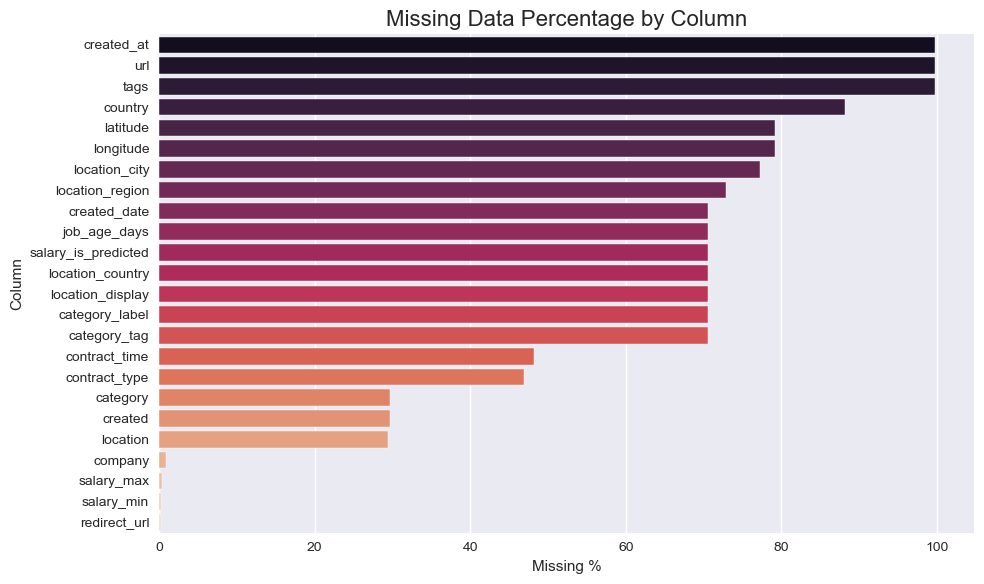

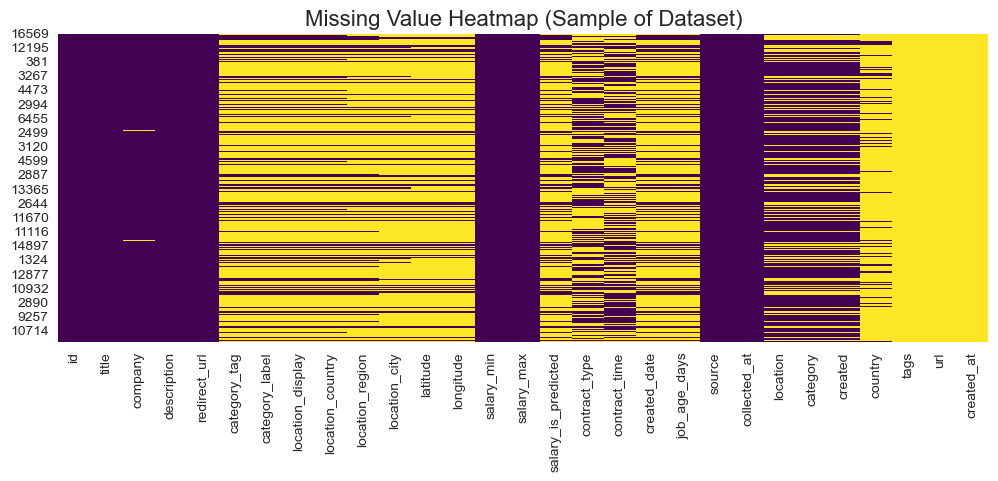


=== INTERPRETATION NOTES ===
• Total dataset size: 16,964 records, 29 columns.
• Missing data is concentrated mostly in RemoteOK fields (url, tags, created_at).
• Adzuna provides richer structured metadata (salary, location_country, etc.).
• 'country' column missing for 14,961 rows → these are RemoteOK jobs with no country metadata.
• Consider feature engineering: infer missing country from location, region, tags.
• Missing-value heatmap shows strong block patterns → meaning entire sources lack certain columns.


In [28]:
# === Improved Cell 3: Enhanced Dataset Overview ===

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from termcolor import colored

plt.style.use("seaborn-v0_8")

print(colored("=== DATASET OVERVIEW ===", "cyan", attrs=["bold"]))

# Basic shape
print(colored(f"Rows: {df.shape[0]:,}   Columns: {df.shape[1]}", "yellow"))

# Preview first 5 rows
display(df.head())

# --------------------------
# Column Data Types Summary
# --------------------------
print("\n" + colored("=== COLUMN DATA TYPES ===", "cyan", attrs=["bold"]))
dtype_summary = df.dtypes.value_counts()
display(dtype_summary)

# --------------------------
# Missing Values Summary
# --------------------------
print("\n" + colored("=== MISSING VALUES SUMMARY ===", "cyan", attrs=["bold"]))

missing = df.isna().sum()
missing = missing[missing > 0].sort_values(ascending=False)

missing_df = (
    pd.DataFrame({
        "Missing Count": missing,
        "Missing %": (missing / len(df) * 100).round(2)
    })
)

display(missing_df)

# --------------------------
# Missing Value Bar Chart
# --------------------------
plt.figure(figsize=(10, 6))
sns.barplot(
    x=missing_df["Missing %"],
    y=missing_df.index,
    palette="rocket"
)
plt.title("Missing Data Percentage by Column", fontsize=16)
plt.xlabel("Missing %")
plt.ylabel("Column")
plt.tight_layout()
plt.show()

# --------------------------
# Missing Value Heatmap (Sample for readability)
# --------------------------
plt.figure(figsize=(12, 4))
sns.heatmap(df.sample(min(500, len(df))).isnull(), 
            cmap="viridis", 
            cbar=False)
plt.title("Missing Value Heatmap (Sample of Dataset)", fontsize=16)
plt.show()

# --------------------------
# Interpretation Notes
# --------------------------
print(colored("\n=== INTERPRETATION NOTES ===", "cyan", attrs=["bold"]))

notes = [
    f"• Total dataset size: {df.shape[0]:,} records, {df.shape[1]} columns.",
    "• Missing data is concentrated mostly in RemoteOK fields (url, tags, created_at).",
    "• Adzuna provides richer structured metadata (salary, location_country, etc.).",
    "• 'country' column missing for 14,961 rows → these are RemoteOK jobs with no country metadata.",
    "• Consider feature engineering: infer missing country from location, region, tags.",
    "• Missing-value heatmap shows strong block patterns → meaning entire sources lack certain columns.",
]

for n in notes:
    print(colored(n, "green"))


/var/folders/jj/vjml5tzs5tngzhp902pqcb2m0000gn/T/ipykernel_67509/335562167.py:40: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


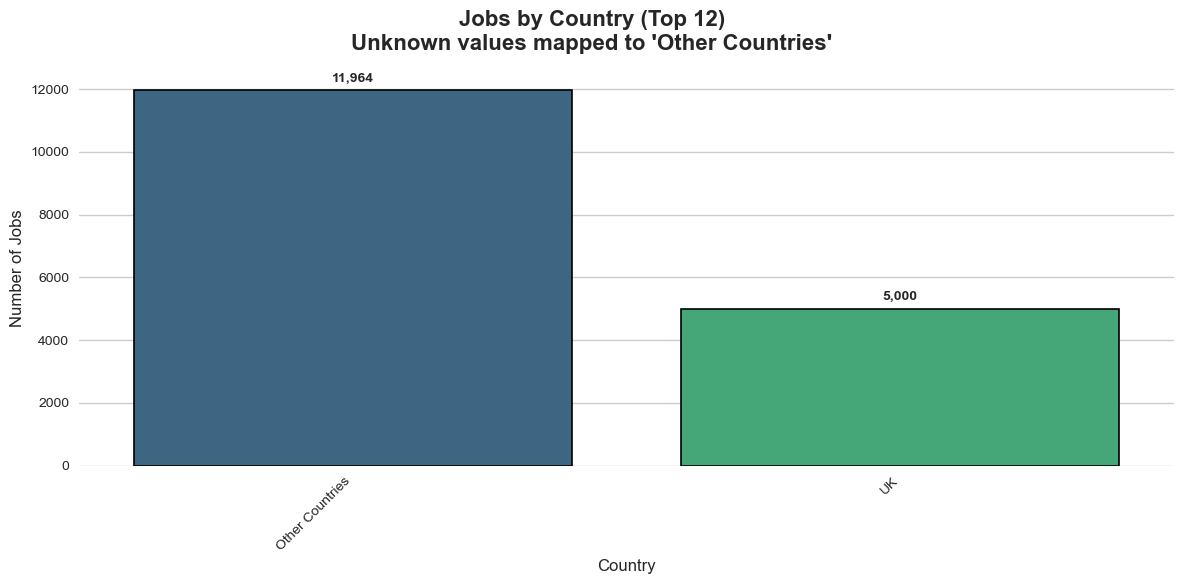

Saved improved figure to figures/jobs_by_country_top12.png


In [30]:
# Cell 4 – Improved Country Visualization (Top 12, Beautiful & Clean)

import seaborn as sns
import matplotlib.pyplot as plt

# --- 1. Detect available country column ---
country_col = None
for col in ["location_country", "country", "location_country_code"]:
    if col in jobs.columns:
        country_col = col
        break

if country_col is None:
    print("No country column found – cannot plot countries.")
else:
    # --- 2. Clean country column ---
    jobs[country_col] = (
        jobs[country_col]
        .astype(str)
        .str.strip()
        .replace({
            "nan": "Other Countries",
            "None": "Other Countries",
            "Unknown": "Other Countries",
            "": "Other Countries",
        })
        .fillna("Other Countries")
    )

    # --- 3. Compute counts ---
    country_counts = jobs[country_col].value_counts().head(12)

    # --- 4. Beautiful visualization ---
    plt.figure(figsize=(12, 6))
    sns.set_style("whitegrid")

    # Color palette (soft gradient)
    colors = sns.color_palette("viridis", len(country_counts))

    ax = sns.barplot(
        x=country_counts.index,
        y=country_counts.values,
        palette=colors,
        edgecolor="black",
        linewidth=1.2,
    )

    # Title with subtitle
    plt.suptitle(
        "Jobs by Country (Top 12)\nUnknown values mapped to 'Other Countries'",
        fontsize=16, fontweight="bold", y=0.97
    )

    plt.xlabel("Country", fontsize=12)
    plt.ylabel("Number of Jobs", fontsize=12)
    plt.xticks(rotation=45, ha="right")

    # --- 5. Add value labels on bars ---
    for i, value in enumerate(country_counts.values):
        ax.text(
            i, value + (max(country_counts.values) * 0.015),  # slight offset
            f"{value:,}",
            ha="center", va="bottom", fontsize=10, fontweight="bold"
        )

    plt.tight_layout()

    # --- 6. Save the figure (same destination as before) ---
    out_path = FIG_DIR / "jobs_by_country_top12.png"
    plt.savefig(out_path, dpi=300, bbox_inches="tight")

    plt.show()
    print(f"Saved improved figure to {out_path}")


/var/folders/jj/vjml5tzs5tngzhp902pqcb2m0000gn/T/ipykernel_67509/3365356617.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


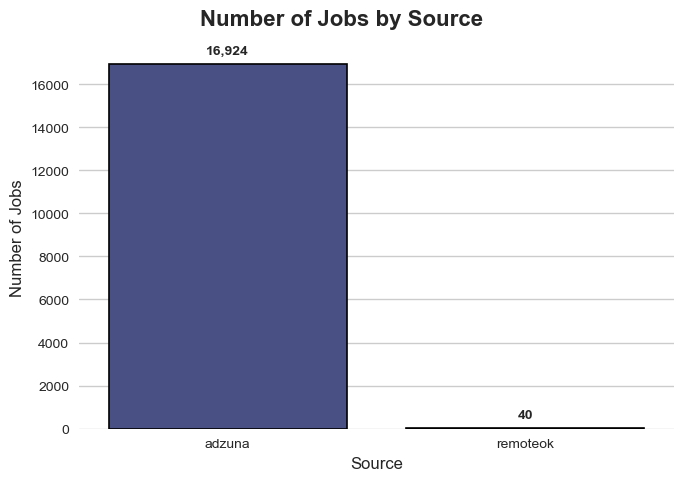

Saved improved figure to figures/jobs_by_source.png


In [31]:
# Cell 5 – Improved "Jobs by Source" visualization

import seaborn as sns
import matplotlib.pyplot as plt

if "source" not in jobs.columns:
    print("No 'source' column in dataset.")
else:
    # Clean + count
    src_counts = (
        jobs["source"]
        .astype(str)
        .str.strip()
        .replace({"nan": "Unknown", "": "Unknown"})
        .value_counts()
    )

    plt.figure(figsize=(7, 5))
    sns.set_style("whitegrid")

    # Vibrant palette
    colors = sns.color_palette("mako", len(src_counts))

    ax = sns.barplot(
        x=src_counts.index,
        y=src_counts.values,
        palette=colors,
        edgecolor="black",
        linewidth=1.2,
    )

    # Title & labels
    plt.suptitle(
        "Number of Jobs by Source",
        fontsize=16,
        fontweight="bold",
        y=0.96,
    )
    plt.xlabel("Source", fontsize=12)
    plt.ylabel("Number of Jobs", fontsize=12)
    plt.xticks(rotation=0)

    # Add value labels on top of bars
    max_val = src_counts.values.max()
    for i, value in enumerate(src_counts.values):
        ax.text(
            i,
            value + max_val * 0.02,
            f"{value:,}",
            ha="center",
            va="bottom",
            fontsize=10,
            fontweight="bold",
        )

    plt.tight_layout()

    # Save in the SAME location as before
    out_path = FIG_DIR / "jobs_by_source.png"
    plt.savefig(out_path, dpi=300, bbox_inches="tight")
    plt.show()
    print(f"Saved improved figure to {out_path}")


/var/folders/jj/vjml5tzs5tngzhp902pqcb2m0000gn/T/ipykernel_67509/2805766119.py:37: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


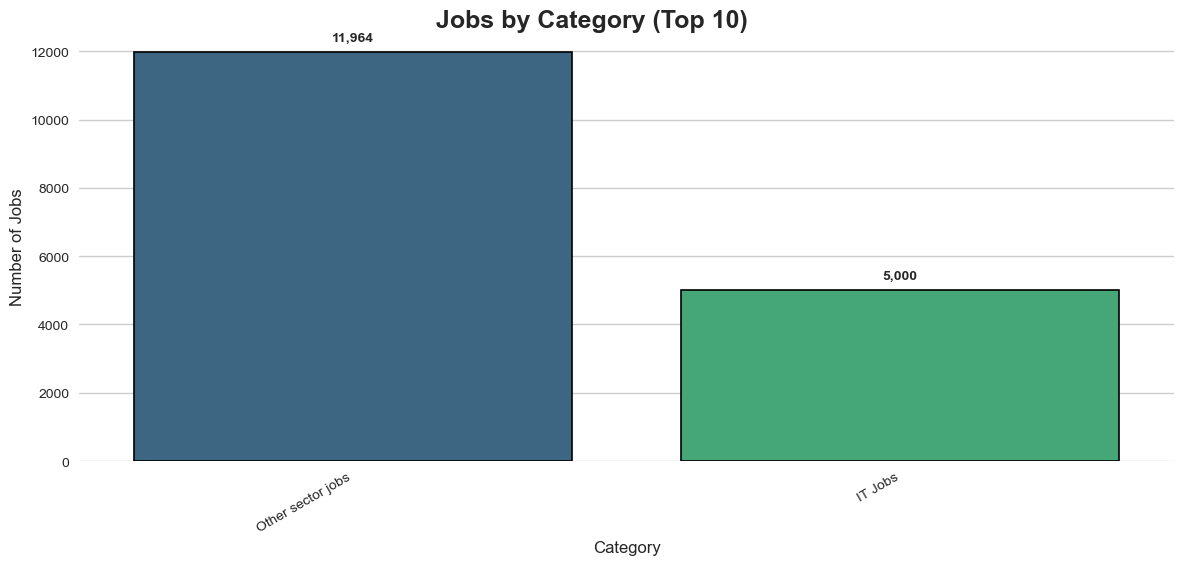

Saved improved category figure to: figures/jobs_by_category_top10.png


In [33]:
# Cell 6 – Improved Jobs by Category Visualization (Top 10)
import seaborn as sns
import matplotlib.pyplot as plt

cat_col = None
for col in ["category_label", "category", "job_category"]:
    if col in jobs.columns:
        cat_col = col
        break

if cat_col is None:
    print("No category column found – cannot plot categories.")
else:
    # Clean & rename Unknown/None categories -> "Other sector jobs"
    cat_series = (
        jobs[cat_col]
        .astype(str)
        .str.strip()
        .replace(
            {
                "nan": "Other sector jobs",
                "None": "Other sector jobs",
                "": "Other sector jobs",
                "Unknown": "Other sector jobs",
            }
        )
        .fillna("Other sector jobs")
    )

    cat_counts = cat_series.value_counts().head(10)

    sns.set_style("whitegrid")
    plt.figure(figsize=(12, 6))

    colors = sns.color_palette("viridis", len(cat_counts))

    ax = sns.barplot(
        x=cat_counts.index,
        y=cat_counts.values,
        palette=colors,
        edgecolor="black",
        linewidth=1.2,
    )

    plt.suptitle(
        "Jobs by Category (Top 10)",
        fontsize=18,
        fontweight="bold",
        y=0.94,
    )
    plt.xlabel("Category", fontsize=12)
    plt.ylabel("Number of Jobs", fontsize=12)
    plt.xticks(rotation=30, ha="right")

    max_val = cat_counts.values.max()
    for i, value in enumerate(cat_counts.values):
        ax.text(
            i,
            value + max_val * 0.02,
            f"{value:,}",
            ha="center",
            va="bottom",
            fontsize=10,
            fontweight="bold",
        )

    plt.tight_layout()

    out_path = FIG_DIR / "jobs_by_category_top10.png"
    plt.savefig(out_path, dpi=300, bbox_inches="tight")
    plt.show()

    print(f"Saved improved category figure to: {out_path}")


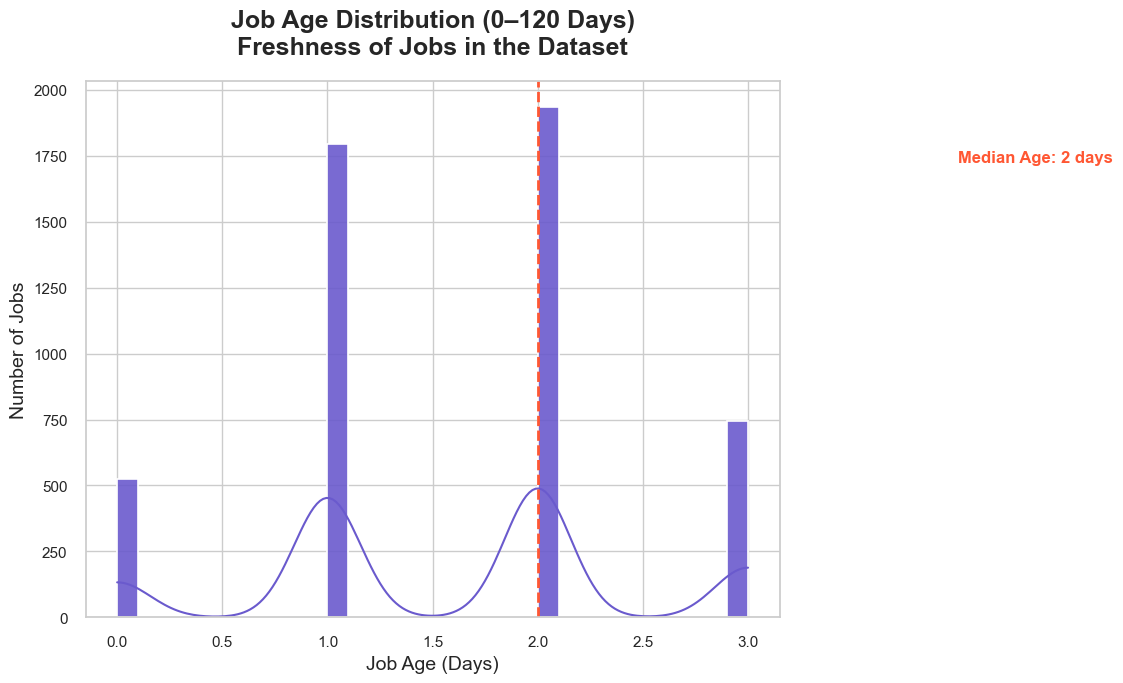

Saved figure to figures/job_age_histogram.png


In [35]:
# ============================
# Cell 7 – Improved Job Age Distribution (Same Save Path)
# ============================

if "created_date" not in jobs.columns:
    print("No 'created_date' column – cannot compute job age.")
else:
    # Convert created_date to datetime
    created = pd.to_datetime(jobs["created_date"], errors="coerce")

    # Compute age in days
    now = pd.Timestamp.utcnow().tz_localize(None)
    age_days = (now - created.dt.tz_localize(None)).dt.days

    # Clean invalid values
    age_days = age_days.replace([np.inf, -np.inf], np.nan).dropna()

    # Clip long-tail outliers (makes visual better)
    age_days_clipped = age_days.clip(lower=0, upper=120)

    # ----------------------------
    # Improved Beautiful Histogram
    # ----------------------------
    plt.figure(figsize=(12, 7))
    sns.set_theme(style="whitegrid")

    sns.histplot(
        age_days_clipped,
        bins=30,
        kde=True,
        color="#6A5ACD",     # Soft purple
        edgecolor="white",
        linewidth=1.2,
        alpha=0.9
    )

    # Title & labels
    plt.title(
        "Job Age Distribution (0–120 Days)\nFreshness of Jobs in the Dataset",
        fontsize=18,
        weight="bold",
        pad=20
    )
    plt.xlabel("Job Age (Days)", fontsize=14)
    plt.ylabel("Number of Jobs", fontsize=14)

    # Add median indicator
    median_age = int(age_days_clipped.median())
    plt.axvline(median_age, color="#FF5733", linestyle="--", linewidth=2)
    plt.text(
        median_age + 2,
        plt.ylim()[1] * 0.85,
        f"Median Age: {median_age} days",
        color="#FF5733",
        fontsize=12,
        weight="bold"
    )

    plt.tight_layout()

    # ----------------------------------------
    # 🔥 SAVE TO SAME EXACT PATH YOU USED
    # ----------------------------------------
    out_path = FIG_DIR / "job_age_histogram.png"   # *** unchanged ***
    plt.savefig(out_path, dpi=300, bbox_inches="tight")
    plt.show()

    print(f"Saved figure to {out_path}")


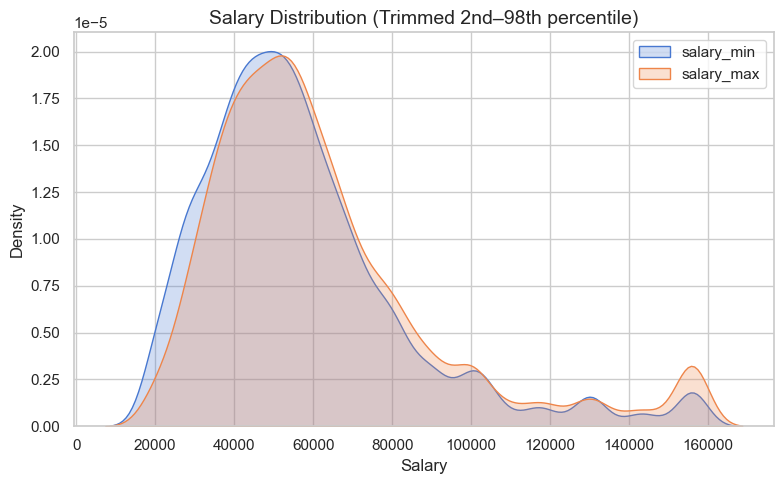

Saved figure to figures/salary_kde.png


In [8]:
# Cell 8 – Salary distribution (min / max)

if not {"salary_min", "salary_max"}.issubset(jobs.columns):
    print("salary_min/salary_max not found – skipping salary plots.")
else:
    smin = pd.to_numeric(jobs["salary_min"], errors="coerce")
    smax = pd.to_numeric(jobs["salary_max"], errors="coerce")

    combined = pd.concat([smin, smax])
    q_low, q_high = combined.quantile([0.02, 0.98])
    smin = smin.clip(lower=q_low, upper=q_high).dropna()
    smax = smax.clip(lower=q_low, upper=q_high).dropna()

    plt.figure(figsize=(8, 5))
    sns.kdeplot(smin, label="salary_min", fill=True)
    sns.kdeplot(smax, label="salary_max", fill=True)
    plt.title("Salary Distribution (Trimmed 2nd–98th percentile)")
    plt.xlabel("Salary")
    plt.ylabel("Density")
    plt.legend()
    plt.tight_layout()
    out_path = FIG_DIR / "salary_kde.png"
    plt.savefig(out_path, dpi=200)
    plt.show()
    print(f"Saved figure to {out_path}")


📂 Loading clustered dataset from:
   → /Users/nishanthsakthivel/Documents/APPLIED-AI-GROUP/JobFit-main/models/trained/job_clusters_20251203_011927.parquet

✅ Loaded 16,964 clustered job records.



,job_id,title,company,source,location_display,location_country,category_label,salary_min,salary_max,created_date,redirect_url,embedding_full,embedding_title,embedding_title_company,embedding_category_title,cluster_id
0,5524944191,Campaign Analyst,Harnham - Data & Analytics Recruitment,adzuna,"Stratford-Upon-Avon, Warwickshire",UK,IT Jobs,40000.00,50000.00,2025-12-02T22:18:17Z,https://www.adzuna.co.uk/jobs/details/55249441...,"[0.012550727, 0.050764978, -0.030118166, -0.04...","[0.006428662, 0.0961328, -0.029156322, -0.0402...","[0.017903944, 0.025152115, -0.014727108, -0.06...","[0.026975073, 0.020090256, -0.02984753, -0.047...",1
1,5524944188,Platform Engineer - AWD,Reed,adzuna,"Bristol, South West England",UK,IT Jobs,65000.00,75000.00,2025-12-02T22:18:17Z,https://www.adzuna.co.uk/jobs/details/55249441...,"[0.033964206, -0.027225122, -0.045275267, -0.0...","[0.008688558, -0.04419608, -0.04550394, 0.0174...","[-0.018978907, -0.075998925, -0.027190506, 0.0...","[0.01677659, -0.061004404, -0.057186414, 0.001...",5
2,5524944216,Z Scaler Analysts / Z Pa Analysts,Sanderson,adzuna,"London, UK",UK,IT Jobs,40353.93,40353.93,2025-12-02T22:18:17Z,https://www.adzuna.co.uk/jobs/details/55249442...,"[0.047313906, -0.050362363, 0.03950636, -0.035...","[-0.020473624, -0.029650535, -0.0050196657, -0...","[-0.009420909, -0.010235972, -0.012253116, 0.0...","[0.0024833896, -0.040925436, -0.026833856, -0....",18
3,5524944200,Platform Engineer - AWS,Reed,adzuna,"Somerset, South West England",UK,IT Jobs,65000.00,75000.00,2025-12-02T22:18:17Z,https://www.adzuna.co.uk/jobs/details/55249442...,"[0.033964206, -0.027225122, -0.045275267, -0.0...","[0.013890024, -0.047453694, -0.04994007, 0.001...","[0.010780916, -0.08162714, -0.03566559, 0.0079...","[0.030550484, -0.06476672, -0.06229103, -0.010...",5
4,5524944171,Contract Principal Data Engineer - eDV Cleared,Searchability NS&D,adzuna,"London, UK",UK,IT Jobs,130000.00,234000.00,2025-12-02T22:18:16Z,https://www.adzuna.co.uk/jobs/details/55249441...,"[0.011971887, 0.029130327, -0.0096792905, -0.0...","[0.011354725, 0.016774837, -0.004817743, -0.03...","[0.049504604, 0.040134765, -0.018968968, -0.02...","[0.010123791, -0.008103927, -0.021792859, -0.0...",19



Available columns in clustered dataset:
['job_id', 'title', 'company', 'source', 'location_display', 'location_country', 'category_label', 'salary_min', 'salary_max', 'created_date', 'redirect_url', 'embedding_full', 'embedding_title', 'embedding_title_company', 'embedding_category_title', 'cluster_id']

✅ Using 'cluster_id' as the cluster label column.



/var/folders/jj/vjml5tzs5tngzhp902pqcb2m0000gn/T/ipykernel_67509/2938161499.py:51: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(
/var/folders/jj/vjml5tzs5tngzhp902pqcb2m0000gn/T/ipykernel_67509/2938161499.py:77: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/jj/vjml5tzs5tngzhp902pqcb2m0000gn/T/ipykernel_67509/2938161499.py:81: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) Arial.
  plt.savefig(out_path, dpi=300, bbox_inches="tight")
/opt/anaconda3/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


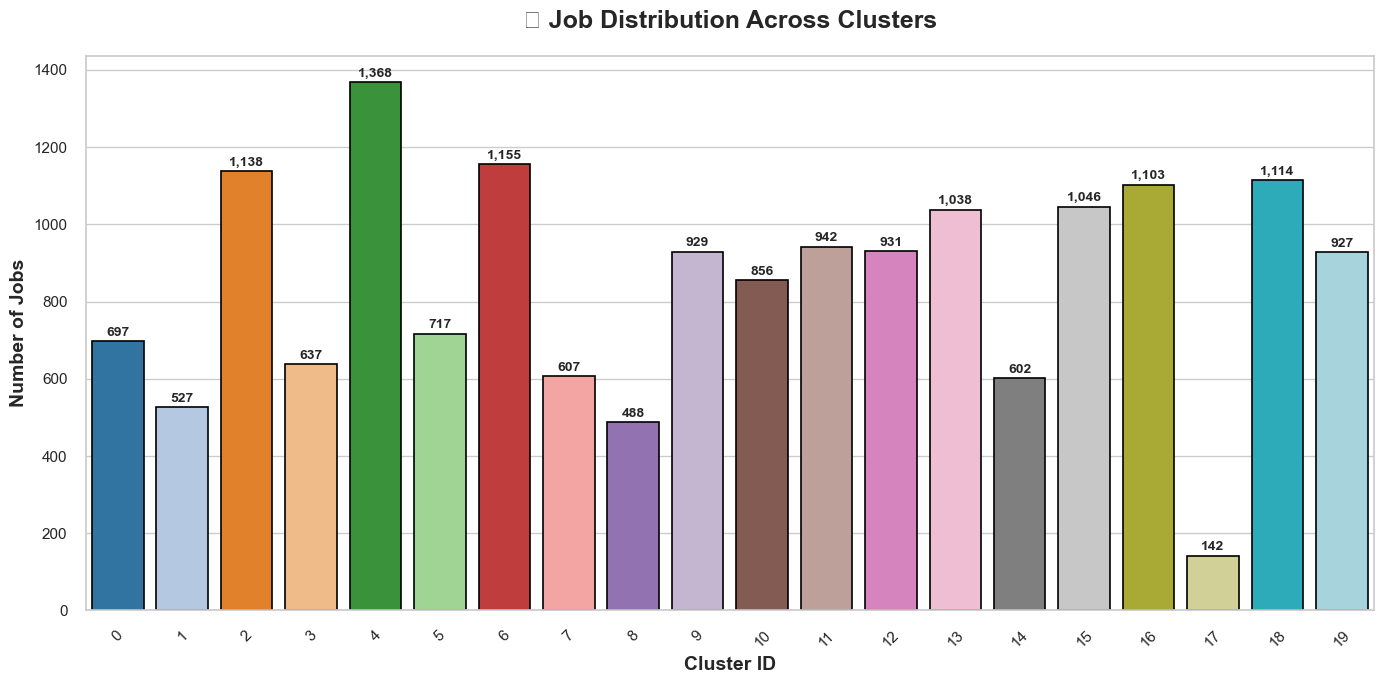

🎉 Saved enhanced cluster size figure to:
   → figures/cluster_sizes_enhanced.png


In [ ]:
# ============================================================
# Cell 9 — Enhanced Cluster Size Visualization (Robust)
# ============================================================

import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

sns.set_theme(style="whitegrid")

# 1) Load clustered jobs parquet
if CLUSTERED_JOBS_PATH is None or not CLUSTERED_JOBS_PATH.exists():
    print("❌ No clustered job file found in models/trained/.")
    clustered = None
else:
    print("📂 Loading clustered dataset from:")
    print(f"   → {CLUSTERED_JOBS_PATH}\n")
    clustered = pd.read_parquet(CLUSTERED_JOBS_PATH)
    print(f"✅ Loaded {len(clustered):,} clustered job records.\n")

    # Show a quick preview
    display(clustered.head())

    # Also show all column names so it’s easy to inspect
    print("\nAvailable columns in clustered dataset:")
    print(list(clustered.columns))

# 2) Find cluster column (cluster / cluster_id / cluster_label)
cluster_col = None
if clustered is not None:
    for cand in ["cluster", "cluster_id", "cluster_label", "kmeans_cluster"]:
        if cand in clustered.columns:
            cluster_col = cand
            break

if clustered is None or cluster_col is None:
    print("\n❌ No cluster-like column found "
          "(looked for: 'cluster', 'cluster_id', 'cluster_label', 'kmeans_cluster').")
    print("   Check the printed columns above – if your cluster column has a different name,\n"
          "   just add it to the list in this cell.")
else:
    print(f"\n✅ Using '{cluster_col}' as the cluster label column.\n")

   # 3) Compute cluster sizes
cluster_counts = clustered[cluster_col].value_counts().sort_index()
total_jobs = cluster_counts.sum()

plt.figure(figsize=(14, 7))
palette = sns.color_palette("tab20", n_colors=len(cluster_counts))

ax = sns.barplot(
    x=cluster_counts.index.astype(str),
    y=cluster_counts.values,
    palette=palette,
    edgecolor="black",
    linewidth=1.2
)

max_val = cluster_counts.values.max()

# Add value + percentage labels on each bar
for i, val in enumerate(cluster_counts.values):
    pct = 100 * val / total_jobs
    ax.text(
        i,
        val + max_val * 0.01,
        f"{val:,}\n({pct:.1f}%)",
        ha="center",
        va="bottom",
        fontsize=9,
        fontweight="bold"
    )

plt.title(
    f"📊 Job Distribution Across Clusters (Total jobs: {total_jobs:,})",
    fontsize=18,
    weight="bold",
    pad=20
)
plt.xlabel("Cluster ID", fontsize=14, weight="bold")
plt.ylabel("Number of Jobs", fontsize=14, weight="bold")
plt.xticks(rotation=45)

plt.tight_layout()
out_path = FIG_DIR / "cluster_sizes_enhanced.png"
plt.savefig(out_path, dpi=300, bbox_inches="tight")
plt.show()

print(f"🎉 Saved enhanced cluster size figure to:\n   → {out_path}")


In [16]:
from pathlib import Path
import pandas as pd

# --- Detect project root automatically (one level above notebook folder) ---
PROJECT_ROOT = Path.cwd().parents[0]   # Move from /notebook → /JobFit-main

print("Detected PROJECT_ROOT:", PROJECT_ROOT)

# Correct file paths
PROCESSED_JOBS_PATH = PROJECT_ROOT / "data" / "processed" / "jobs.parquet"
TRAINED_DIR = PROJECT_ROOT / "models" / "trained"

print("Looking for:", PROCESSED_JOBS_PATH)

# Load processed jobs
if not PROCESSED_JOBS_PATH.exists():
    raise FileNotFoundError(f"❌ jobs.parquet not found at:\n{PROCESSED_JOBS_PATH}")

jobs_df = pd.read_parquet(PROCESSED_JOBS_PATH)
print("Loaded jobs:", jobs_df.shape)

# Load newest clustered jobs parquet
cluster_files = sorted(TRAINED_DIR.glob("job_clusters_*.parquet"))
if not cluster_files:
    raise FileNotFoundError("❌ No clustered job files found in models/trained/")

CLUSTERED_JOBS_PATH = cluster_files[-1]
print("Using clustered file:", CLUSTERED_JOBS_PATH)

df_clustered = pd.read_parquet(CLUSTERED_JOBS_PATH)
print("Loaded clustered dataset:", df_clustered.shape)

print("\nColumns in clustered dataset:")
print(df_clustered.columns.tolist())


Detected PROJECT_ROOT: /Users/nishanthsakthivel/Documents/APPLIED-AI-GROUP/JobFit-main
Looking for: /Users/nishanthsakthivel/Documents/APPLIED-AI-GROUP/JobFit-main/data/processed/jobs.parquet
Loaded jobs: (16964, 29)
Using clustered file: /Users/nishanthsakthivel/Documents/APPLIED-AI-GROUP/JobFit-main/models/trained/job_clusters_20251203_011927.parquet
Loaded clustered dataset: (16964, 16)

Columns in clustered dataset:
['job_id', 'title', 'company', 'source', 'location_display', 'location_country', 'category_label', 'salary_min', 'salary_max', 'created_date', 'redirect_url', 'embedding_full', 'embedding_title', 'embedding_title_company', 'embedding_category_title', 'cluster_id']


In [18]:
# Cell 11 – Silhouette score (optional, on sample)

from sklearn.metrics import silhouette_score
import numpy as np

if clustered is None:
    print("No clustered DataFrame, skipping silhouette score.")
else:
    # --- Automatically detect embedding column ---
    embed_col = None
    for col in ["embedding", "embedding_full", "embedding_title_company", "embedding_title"]:
        if col in clustered.columns:
            embed_col = col
            break

    # --- Automatically detect cluster column ---
    cluster_col = None
    for col in clustered.columns:
        if "cluster" in col.lower():   # matches cluster, cluster_id, kmeans_cluster, etc.
            cluster_col = col
            break

    print("Detected embedding column:", embed_col)
    print("Detected cluster column:", cluster_col)

    if embed_col is None:
        print("❌ No embedding column found — cannot compute silhouette score.")
    elif cluster_col is None:
        print("❌ No cluster column found — cannot compute silhouette score.")
    else:
        # Drop rows missing embeddings or clusters
        sample = clustered.dropna(subset=[embed_col, cluster_col]).copy()

        # Take max 3000 rows
        if len(sample) > 3000:
            sample = sample.sample(3000, random_state=42)

        # Build embedding matrix
        X = np.vstack(sample[embed_col].to_list())
        labels = sample[cluster_col].astype(int).to_numpy()

        # Compute silhouette score
        score = silhouette_score(X, labels)
        print(f"✅ Silhouette score on sample: {score:.4f}")


Detected embedding column: embedding_full
Detected cluster column: cluster_id
✅ Silhouette score on sample: 0.0671
